<a href="https://colab.research.google.com/github/ashrafsohail42003/ML---Cirrhosis-Prediction-Dataset-/blob/main/Cirrhosis_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [38]:
file_path = '/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week09/Data/cirrhosis.csv'
df = pd.read_csv(file_path)

In [39]:
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [41]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [42]:
duplicate_count = df.duplicated().sum()
print(f"Identified Duplicate Rows: {duplicate_count}")

Identified Duplicate Rows: 0


In [43]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Counts': null_counts, 'Percentage (%)': null_percentages})
missing_summary.sort_values(by='Missing Counts', ascending=False)

,Missing Counts,Percentage (%)
Tryglicerides,136,32.535885
Cholesterol,134,32.057416
Copper,108,25.837321
Drug,106,25.358852
Alk_Phos,106,25.358852
SGOT,106,25.358852
Spiders,106,25.358852
Hepatomegaly,106,25.358852
Ascites,106,25.358852
Platelets,11,2.631579


In [44]:
target_distribution_counts = df['Status'].value_counts()
target_distribution_pct = df['Status'].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({'Counts': target_distribution_counts, 'Proportion (%)': target_distribution_pct})
target_summary

,Counts,Proportion (%)
Status,,
C,232,55.502392
D,161,38.516746
CL,25,5.980861


In [45]:
df.drop(columns=['ID'], inplace=True, errors='ignore')
df['Age_Years'] = df['Age'] / 365.25
df.drop(columns=['Age'], inplace=True)
df['Stage'] = df['Stage'].astype(str).replace('nan', np.nan)
categorical_features_clean = df.select_dtypes(include=['object']).columns
for col in categorical_features_clean:
    df[col] = df[col].astype(str).str.strip().replace('nan', np.nan)

df.head()

,N_Days,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_Years
0,400,D,D-penicillamine,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.765229
1,4500,C,D-penicillamine,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.446270
2,1012,D,D-penicillamine,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.072553
3,1925,D,D-penicillamine,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.740589
4,1504,CL,Placebo,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.105407


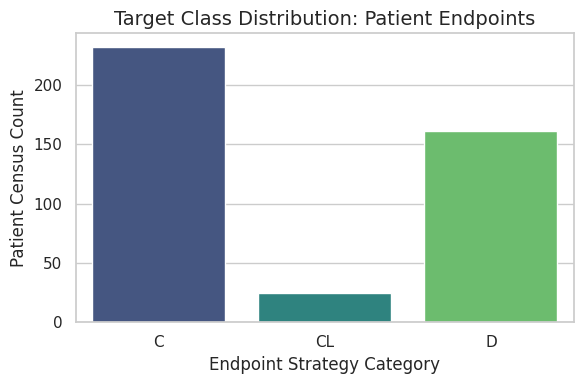

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Status', palette='viridis', order=['C', 'CL', 'D'])
plt.title('Target Class Distribution: Patient Endpoints')
plt.xlabel('Endpoint Strategy Category')
plt.ylabel('Patient Census Count')
plt.tight_layout()
plt.show()

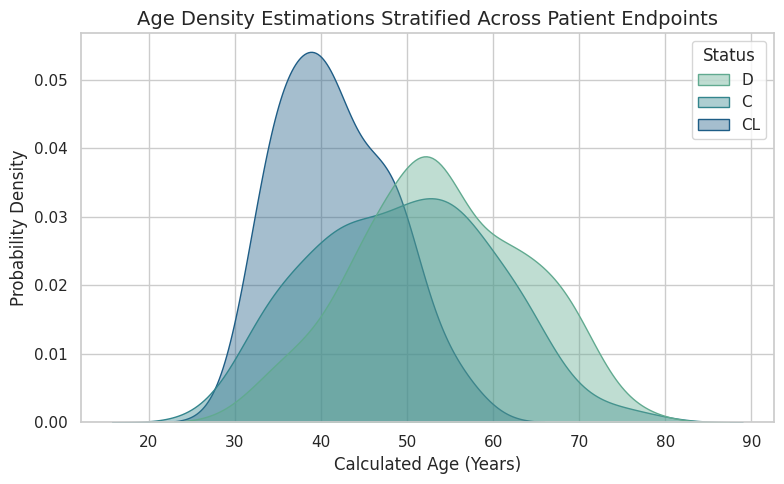

In [47]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age_Years', hue='Status', fill=True, common_norm=False, palette='crest', alpha=0.4)
plt.title('Age Density Estimations Stratified Across Patient Endpoints')
plt.xlabel('Calculated Age (Years)')
plt.ylabel('Probability Density')
plt.tight_layout()
plt.show()

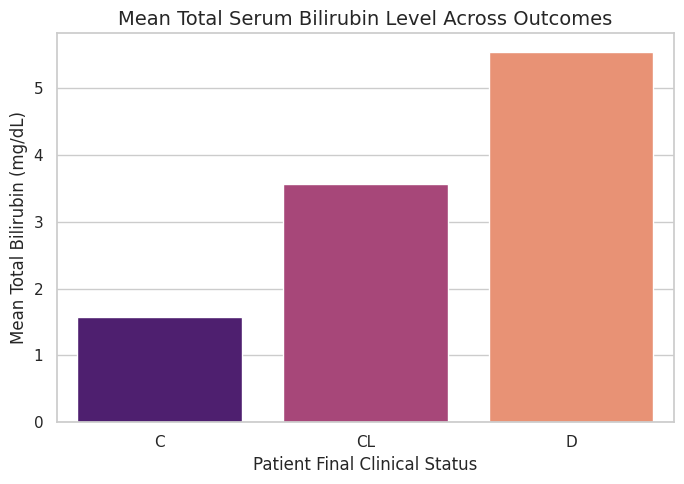

In [48]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Status', y='Bilirubin', palette='magma', errorbar=None, order=['C', 'CL', 'D'])
plt.title('Mean Total Serum Bilirubin Level Across Outcomes')
plt.xlabel('Patient Final Clinical Status')
plt.ylabel('Mean Total Bilirubin (mg/dL)')
plt.tight_layout()
plt.show()

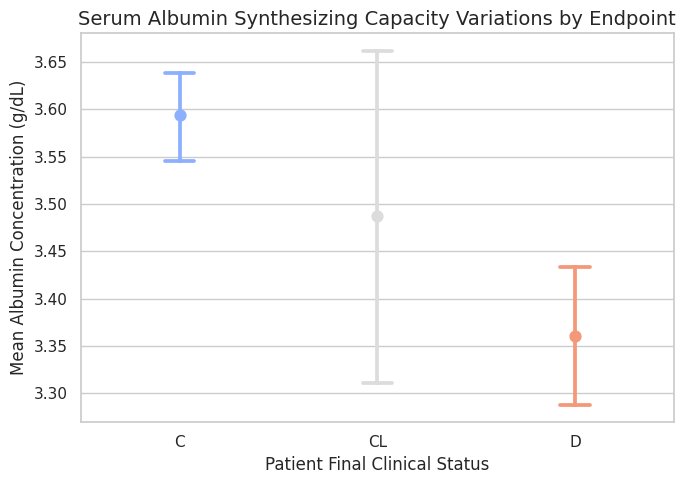

In [49]:
plt.figure(figsize=(7, 5))
sns.pointplot(data=df, x='Status', y='Albumin', palette='coolwarm', join=False, capsize=0.15, order=['C', 'CL', 'D'])
plt.title('Serum Albumin Synthesizing Capacity Variations by Endpoint')
plt.xlabel('Patient Final Clinical Status')
plt.ylabel('Mean Albumin Concentration (g/dL)')
plt.tight_layout()
plt.show()

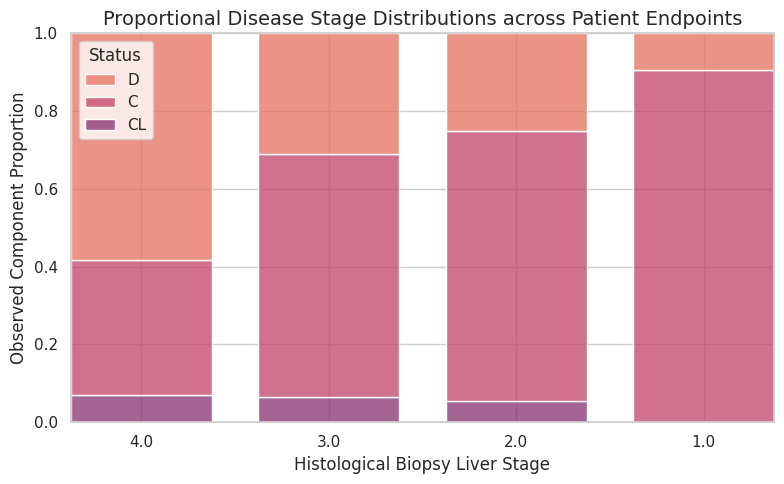

In [50]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Stage', hue='Status', multiple='fill', shrink=0.75, palette='flare')
plt.title('Proportional Disease Stage Distributions across Patient Endpoints')
plt.xlabel('Histological Biopsy Liver Stage')
plt.ylabel('Observed Component Proportion')
plt.tight_layout()
plt.show()

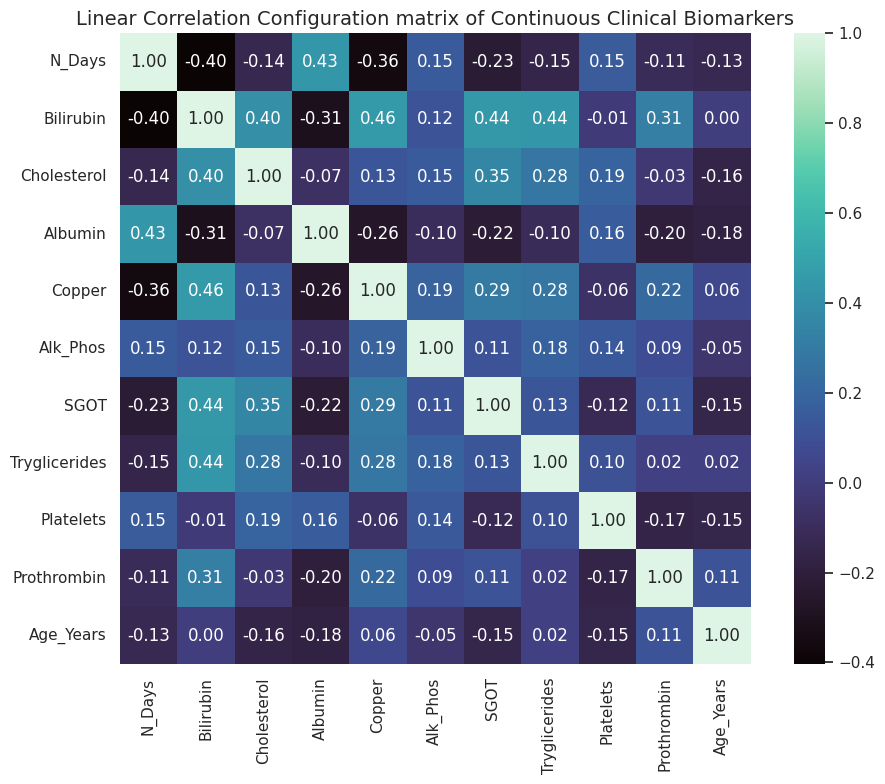

In [51]:
plt.figure(figsize=(10, 8))
numeric_matrix_df = df.select_dtypes(include=[np.number])
correlation_coefficient_matrix = numeric_matrix_df.corr()
sns.heatmap(correlation_coefficient_matrix, annot=True, fmt=".2f", cmap='mako', square=True)
plt.title('Linear Correlation Configuration matrix of Continuous Clinical Biomarkers')
plt.tight_layout()
plt.show()

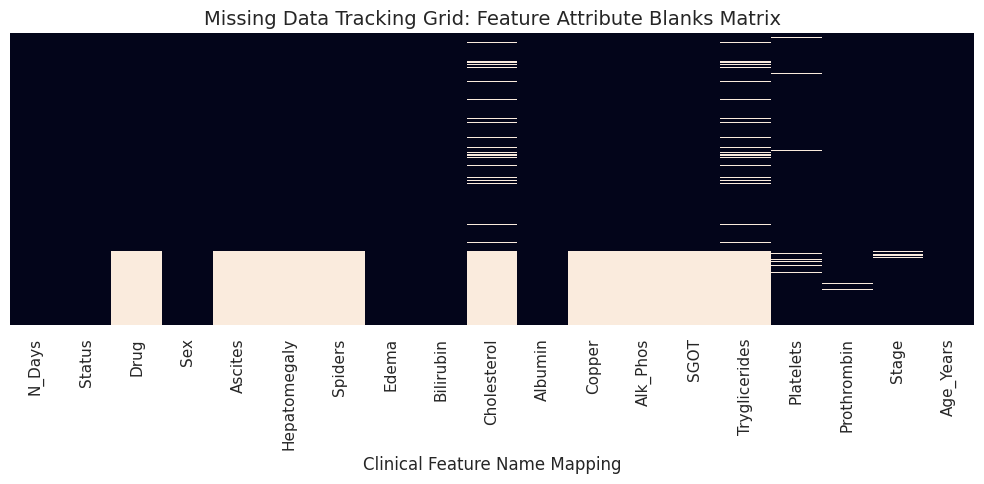

In [52]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='rocket', yticklabels=False)
plt.title('Missing Data Tracking Grid: Feature Attribute Blanks Matrix')
plt.xlabel('Clinical Feature Name Mapping')
plt.tight_layout()
plt.show()

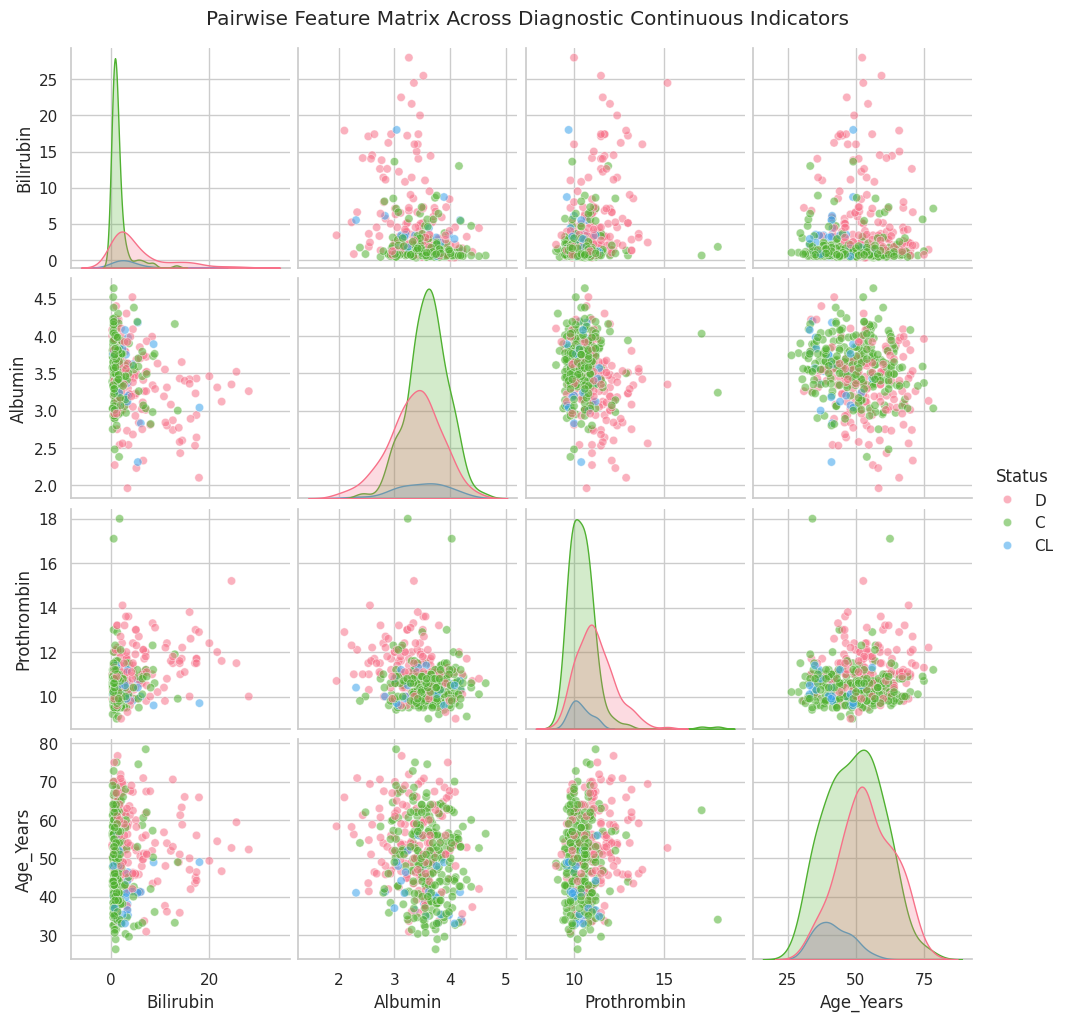

In [53]:
key_clinical_dimensions = ['Bilirubin', 'Albumin', 'Prothrombin', 'Age_Years', 'Status']
sns.pairplot(df[key_clinical_dimensions], hue='Status', palette='husl', diag_kind='kde', plot_kws={'alpha':0.55})
plt.suptitle('Pairwise Feature Matrix Across Diagnostic Continuous Indicators', y=1.02)
plt.show()

In [54]:
df['Bilirubin_Log'] = np.log1p(df['Bilirubin'])
df['Copper_Log'] = np.log1p(df['Copper'].fillna(df['Copper'].median()))
df['Alk_Phos_Log'] = np.log1p(df['Alk_Phos'].fillna(df['Alk_Phos'].median()))
df['SGOT_Log'] = np.log1p(df['SGOT'].fillna(df['SGOT'].median()))
df.drop(columns=['Bilirubin', 'Copper', 'Alk_Phos', 'SGOT'], errors='ignore', inplace=True)
df['Bilirubin_Albumin_Ratio'] = df['Bilirubin_Log'] / (df['Albumin'] + 1e-6)
df.head()

,N_Days,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema,Cholesterol,Albumin,Tryglicerides,Platelets,Prothrombin,Stage,Age_Years,Bilirubin_Log,Copper_Log,Alk_Phos_Log,SGOT_Log,Bilirubin_Albumin_Ratio
0,400,D,D-penicillamine,F,Y,Y,Y,Y,261.0,2.60,172.0,190.0,12.2,4.0,58.765229,2.740840,5.056246,7.449498,4.934114,1.054169
1,4500,C,D-penicillamine,F,N,Y,Y,N,302.0,4.14,88.0,221.0,10.6,3.0,56.446270,0.741937,4.007333,8.908668,4.740749,0.179212
2,1012,D,D-penicillamine,M,N,N,N,S,176.0,3.48,55.0,151.0,12.0,4.0,70.072553,0.875469,5.351858,6.248043,4.575741,0.251571
3,1925,D,D-penicillamine,F,N,Y,Y,S,244.0,2.54,92.0,183.0,10.3,4.0,54.740589,1.029619,4.174387,8.719775,4.121149,0.405362
4,1504,CL,Placebo,F,N,Y,Y,N,279.0,3.53,72.0,136.0,10.9,3.0,38.105407,1.481605,4.969813,6.510258,4.737513,0.419718


In [55]:
X_matrix = df.drop(columns=['Status'])
y_vector = df['Status']
target_label_map = {'C': 0, 'CL': 1, 'D': 2}
y_numerical = y_vector.map(target_label_map).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X_matrix, y_numerical, test_size=0.25, random_state=42, stratify=y_numerical
)
numeric_pipeline_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_pipeline_features = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_processing_block = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_processing_block = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
computational_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_processing_block, numeric_pipeline_features),
        ('cat', categorical_processing_block, categorical_pipeline_features)
    ]
)
print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(313, 19), y=(313,)
Test shapes: X=(105, 19), y=(105,)


In [56]:
baseline_structural_pipeline = Pipeline(steps=[
    ('preprocessor', computational_preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42))
])
baseline_structural_pipeline.fit(X_train, y_train)
y_baseline_predictions = baseline_structural_pipeline.predict(X_test)

print("Baseline Computational Accuracy:", accuracy_score(y_test, y_baseline_predictions))
print("\nBaseline Model Classification Profile Summary:\n", classification_report(y_test, y_baseline_predictions, target_names=['C', 'CL', 'D']))

Baseline Computational Accuracy: 0.780952380952381

Baseline Model Classification Profile Summary:
               precision    recall  f1-score   support

           C       0.80      0.90      0.85        58
          CL       0.00      0.00      0.00         6
           D       0.77      0.73      0.75        41

    accuracy                           0.78       105
   macro avg       0.52      0.54      0.53       105
weighted avg       0.74      0.78      0.76       105



In [57]:
advanced_ensemble_pipeline = Pipeline(steps=[
    ('preprocessor', computational_preprocessor),
    ('classifier', xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42))
])
hyperparameter_search_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 4, 6],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0]
}
stratified_cross_validator = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_execution = GridSearchCV(
    estimator=advanced_ensemble_pipeline,
    param_grid=hyperparameter_search_grid,
    cv=stratified_cross_validator,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search_execution.fit(X_train, y_train)
optimized_production_model = grid_search_execution.best_estimator_
y_advanced_predictions = optimized_production_model.predict(X_test)
y_advanced_probabilities = optimized_production_model.predict_proba(X_test)

print("Optimized Hyperparameters Extracted:", grid_search_execution.best_params_)
print("\nAdvanced Production Model Classification Profile Summary:\n", classification_report(y_test, y_advanced_predictions, target_names=['C', 'CL', 'D']))

Optimized Hyperparameters Extracted: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'classifier__subsample': 0.6}

Advanced Production Model Classification Profile Summary:
               precision    recall  f1-score   support

           C       0.73      0.91      0.81        58
          CL       0.00      0.00      0.00         6
           D       0.83      0.61      0.70        41

    accuracy                           0.74       105
   macro avg       0.52      0.51      0.50       105
weighted avg       0.73      0.74      0.72       105



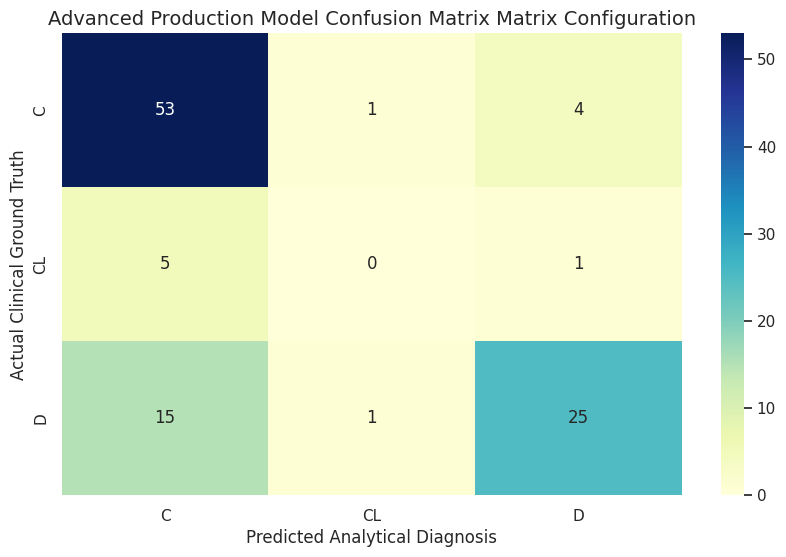

In [58]:
matrix_data_array = confusion_matrix(y_test, y_advanced_predictions)
sns.heatmap(matrix_data_array, annot=True, fmt="d", cmap="YlGnBu", xticklabels=['C', 'CL', 'D'], yticklabels=['C', 'CL', 'D'])
plt.title('Advanced Production Model Confusion Matrix Matrix Configuration')
plt.xlabel('Predicted Analytical Diagnosis')
plt.ylabel('Actual Clinical Ground Truth')
plt.show()

In [59]:
multiclass_auc_metric = roc_auc_score(y_test, y_advanced_probabilities, multi_class='ovr', average='macro')
print(f"Advanced Framework Multi-Class One-vs-Rest Macro AUC: {multiclass_auc_metric:.4f}")

Advanced Framework Multi-Class One-vs-Rest Macro AUC: 0.7272


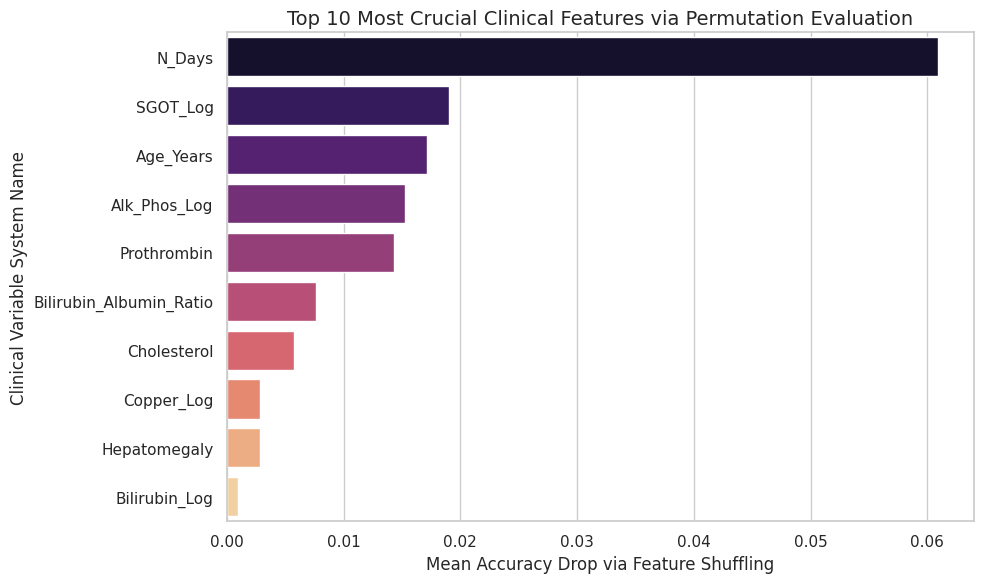

In [60]:
permutation_importance_results = permutation_importance(
    optimized_production_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

sorted_importance_indices = permutation_importance_results.importances_mean.argsort()[::-1]
top_ten_features_indices = sorted_importance_indices[:10]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=permutation_importance_results.importances_mean[top_ten_features_indices],
    y=X_test.columns[top_ten_features_indices],
    palette='magma',
    orient='h'
)
plt.title('Top 10 Most Crucial Clinical Features via Permutation Evaluation')
plt.xlabel('Mean Accuracy Drop via Feature Shuffling')
plt.ylabel('Clinical Variable System Name')
plt.tight_layout()
plt.show()

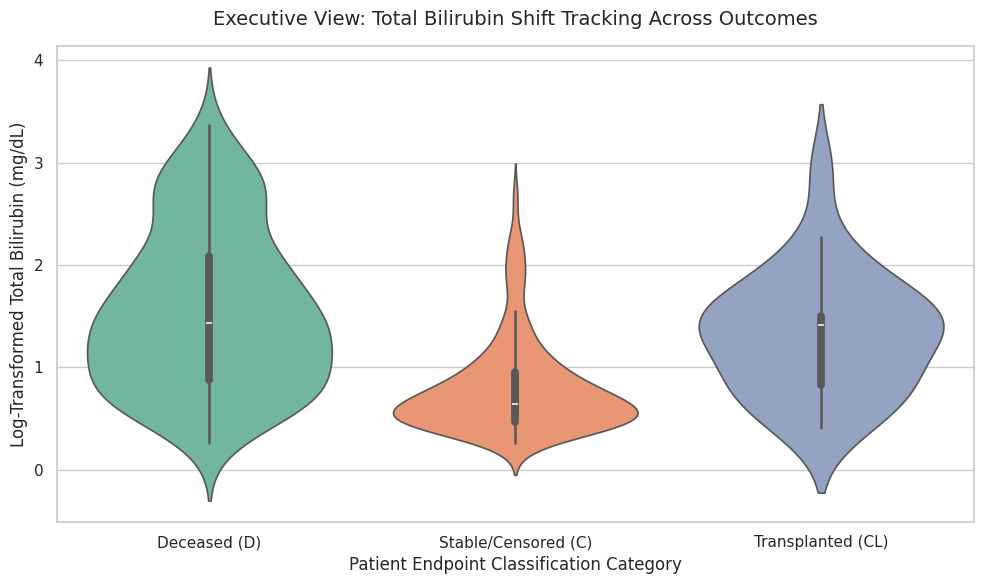

In [61]:
visualization_df = df.copy()
outcome_label_conversion = {0: 'Stable/Censored (C)', 1: 'Transplanted (CL)', 2: 'Deceased (D)'}
visualization_df['Class_Label'] = pd.Series(y_numerical).map(outcome_label_conversion)

plt.figure(figsize=(10, 6))
sns.violinplot(data=visualization_df, x='Class_Label', y='Bilirubin_Log', palette='Set2', inner='box')
plt.title('Executive View: Total Bilirubin Shift Tracking Across Outcomes', fontsize=14, pad=15)
plt.xlabel('Patient Endpoint Classification Category', fontsize=12)
plt.ylabel('Log-Transformed Total Bilirubin (mg/dL)', fontsize=12)
plt.tight_layout()
plt.show()

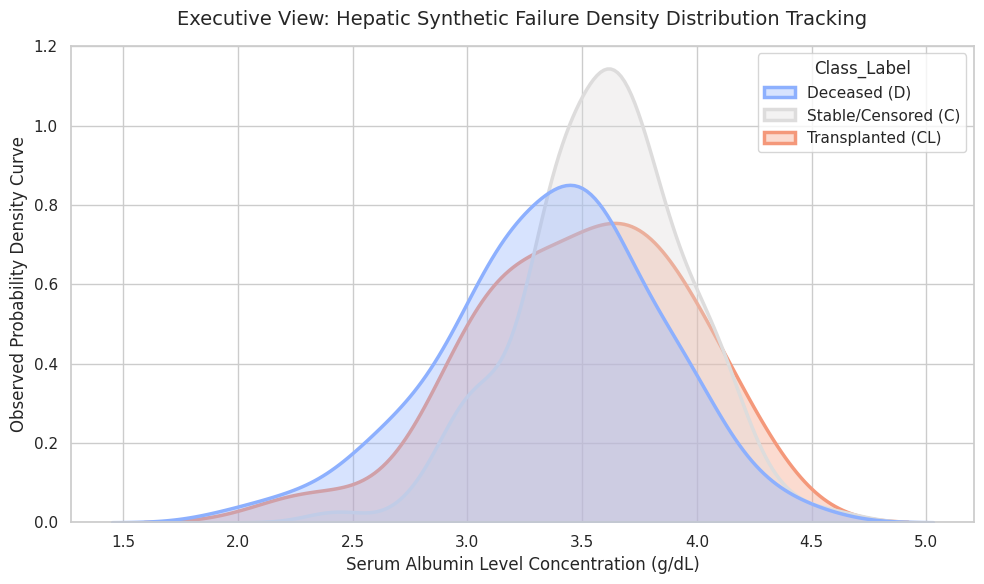

In [62]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=visualization_df, x='Albumin', hue='Class_Label', fill=True, common_norm=False, palette='coolwarm', alpha=0.35, linewidth=2.5)
plt.title('Executive View: Hepatic Synthetic Failure Density Distribution Tracking', fontsize=14, pad=15)
plt.xlabel('Serum Albumin Level Concentration (g/dL)', fontsize=12)
plt.ylabel('Observed Probability Density Curve', fontsize=12)
plt.tight_layout()
plt.show()